# 3 — Hyperparameter Sweep

**Goal:** Find the best learning rate, knowledge distillation temperature, and alpha before full training.

Two stages:
1. **Sweep** — 9 combinations × 5 epochs × 1,000 samples → find best LR, Temperature, Alpha
2. **Medium training** — confirm best params on 5,000 samples with early stopping → find ideal number of epochs

Results feed directly into `4_training.ipynb`.

Run `1_setup_dataset.ipynb` first to extract the dataset.

In [2]:
import os
import sys
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

# Clone repo + add src/ to path
PROJECT_DIR = '/content/project'
SRC_DIR     = os.path.join(PROJECT_DIR, 'src')

if not os.path.exists(PROJECT_DIR):
    !git clone https://github.com/Arjun11x/deepfake-audio-detection.git {PROJECT_DIR}

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

# Configure paths
import config
config.ENV          = "colab"
config.DATASET_ROOT = "/content/asvspoof2019/LA"
config.AUDIO_DIRS   = {
    "train" : "/content/asvspoof2019/LA/ASVspoof2019_LA_train/flac",
    "dev"   : "/content/asvspoof2019/LA/ASVspoof2019_LA_dev/flac",
    "eval"  : "/content/asvspoof2019/LA/ASVspoof2019_LA_eval/flac",
}
config.PROTOCOL_FILES = {
    "train" : "/content/asvspoof2019/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt",
    "dev"   : "/content/asvspoof2019/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt",
    "eval"  : "/content/asvspoof2019/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt",
}
config.SAVE_DIR = "/content/drive/MyDrive/deepfake_detector/models"
os.makedirs(config.SAVE_DIR, exist_ok=True)

# Extract dataset if needed
ZIP_PATH    = '/content/drive/MyDrive/LA.zip'
EXTRACT_DIR = '/content/asvspoof2019'
LA_DIR      = os.path.join(EXTRACT_DIR, 'LA')

if os.path.exists(LA_DIR):
    print(f'✅ Dataset already extracted')
else:
    print(f'Extracting dataset...')
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    !unzip -q {ZIP_PATH} -d {EXTRACT_DIR}
    print(f'✅ Extraction complete')

from models  import MobileStudentCNN, Wav2VecTeacher
from dataset import AudioDeepfakeDataset
from utils   import load_asvspoof2019, compute_eer, kd_loss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n✅ Setup complete | Device: {device}")
print(f"  Dataset root : {config.DATASET_ROOT}")
print(f"  Save dir     : {config.SAVE_DIR}")

Mounted at /content/drive
Cloning into '/content/project'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 23 (delta 2), reused 22 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 349.47 KiB | 13.44 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Extracting dataset...
✅ Extraction complete

✅ Setup complete | Device: cuda
  Dataset root : /content/asvspoof2019/LA
  Save dir     : /content/drive/MyDrive/deepfake_detector/models


In [3]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

## 3.1 — Load Sweep Data + Teacher

Load 1,000 balanced samples for sweep training and 200 for validation.
Teacher is loaded once and shared across all 9 experiments.

In [ ]:
# Load sweep data
print("Loading sweep data...")
train_files, train_labels = load_asvspoof2019(
    config.DATASET_ROOT, config.AUDIO_DIRS, config.PROTOCOL_FILES,
    subset="train", max_samples=1000, balanced=True
)
val_files, val_labels = load_asvspoof2019(
    config.DATASET_ROOT, config.AUDIO_DIRS, config.PROTOCOL_FILES,
    subset="dev", max_samples=200, balanced=True
)

assert train_labels.count(0) == train_labels.count(1), "FAIL: Train not balanced!"
assert val_labels.count(0)   == val_labels.count(1),   "FAIL: Val not balanced!"
print(f"✅ Class balance verified")

train_dataset = AudioDeepfakeDataset(train_files, train_labels, is_training=True)
val_dataset   = AudioDeepfakeDataset(val_files,   val_labels,   is_training=False)

train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f"  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")

# Load teacher once — shared across all experiments
print("\nLoading Teacher (frozen)...")
teacher = Wav2VecTeacher().to(device)
teacher.eval()
print("✅ Teacher loaded and frozen")

**Note:** The output of this cell (Teacher model loading) has been cleared
before pushing to GitHub. The Hugging Face model download progress bar
generates widget metadata that causes GitHub's notebook renderer to show
"Invalid Notebook". The Teacher loads correctly when you run this cell —
it downloads `facebook/wav2vec2-base` (~380MB) on first run and uses
cache on subsequent runs.

## 3.2 — Hyperparameter Sweep

Run 9 combinations × 5 epochs × 1,000 samples.
Goal: find the best Learning Rate, Temperature, and Alpha before committing to full training.

| Parameter | Values tested |
|-----------|--------------|
| Learning Rate | 0.001, 0.0005, 0.0001 |
| Temperature | 4.0, 6.0 |
| Alpha | 0.5, 0.7 |

In [9]:
def run_experiment(lr, temperature, alpha, train_loader, val_loader, num_epochs=5):
    """Train student for num_epochs, return best val_loss and val_acc."""
    student      = MobileStudentCNN().to(device)
    optimizer    = optim.Adam(student.parameters(), lr=lr)
    scheduler    = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    hard_loss_fn = nn.CrossEntropyLoss()
    soft_loss_fn = nn.KLDivLoss(reduction="batchmean")

    best_val_loss = float('inf')
    best_val_acc  = 0.0

    for epoch in range(1, num_epochs + 1):

        # --- Train ---
        student.train()
        for raw_audio, mel_specs, true_labels in train_loader:
            raw_audio   = raw_audio.to(device)
            mel_specs   = mel_specs.to(device)
            true_labels = true_labels.to(device)

            optimizer.zero_grad()
            with torch.no_grad():
                teacher_logits = teacher(raw_audio)

            student_logits = student(mel_specs)
            loss, _, _     = kd_loss(
                student_logits, teacher_logits, true_labels,
                temperature, alpha, hard_loss_fn, soft_loss_fn
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
            optimizer.step()

        scheduler.step()

        # --- Validate ---
        student.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for raw_audio, mel_specs, true_labels in val_loader:
                raw_audio   = raw_audio.to(device)
                mel_specs   = mel_specs.to(device)
                true_labels = true_labels.to(device)

                teacher_logits = teacher(raw_audio)
                student_logits = student(mel_specs)
                loss, _, _     = kd_loss(
                    student_logits, teacher_logits, true_labels,
                    temperature, alpha, hard_loss_fn, soft_loss_fn
                )
                val_loss    += loss.item()
                predicted    = torch.argmax(student_logits, dim=1)
                val_correct += (predicted == true_labels).sum().item()
                val_total   += true_labels.size(0)

        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc  = 100.0 * val_correct / val_total

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_val_acc  = avg_val_acc

    return best_val_loss, best_val_acc


# ==========================================
# Sweep Grid — 9 combinations
# ==========================================
sweep_grid = config.SWEEP_GRID

print(f"{'='*65}")
print(f"  Hyperparameter Sweep — {len(sweep_grid)} combinations × 5 epochs")
print(f"  Train: 1,000 samples | Val: 200 samples")
print(f"{'='*65}")
print(f"  {'LR':<8} {'Temp':<6} {'Alpha':<6} {'Val Loss':<12} {'Val Acc':<10}")
print(f"  {'-'*55}")

sweep_results = []

for i, (lr, temp, alpha) in enumerate(sweep_grid):
    print(f"  Running {i+1}/{len(sweep_grid)}: LR={lr}, T={temp}, Alpha={alpha} ...", end=" ", flush=True)
    val_loss, val_acc = run_experiment(lr, temp, alpha, train_loader, val_loader, num_epochs=5)
    sweep_results.append((lr, temp, alpha, val_loss, val_acc))
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.1f}%")

# Sort by val_loss
sweep_results.sort(key=lambda x: x[3])

print(f"\n{'='*65}")
print(f"  SWEEP RESULTS — sorted by Val Loss (lower is better)")
print(f"{'='*65}")
print(f"  {'Rank':<6} {'LR':<8} {'Temp':<6} {'Alpha':<6} {'Val Loss':<12} {'Val Acc':<10}")
print(f"  {'-'*55}")
for rank, (lr, temp, alpha, val_loss, val_acc) in enumerate(sweep_results, 1):
    marker = " ← BEST" if rank == 1 else ""
    print(f"  {rank:<6} {lr:<8} {temp:<6} {alpha:<6} {val_loss:<12.4f} {val_acc:<10.1f}%{marker}")

# Save best params
best_lr    = sweep_results[0][0]
best_temp  = sweep_results[0][1]
best_alpha = sweep_results[0][2]

print(f"\n✅ Best Parameters Found:")
print(f"   LR          : {best_lr}")
print(f"   Temperature : {best_temp}")
print(f"   Alpha       : {best_alpha}")

  Hyperparameter Sweep — 9 combinations × 5 epochs
  Train: 1,000 samples | Val: 200 samples
  LR       Temp   Alpha  Val Loss     Val Acc   
  -------------------------------------------------------
  Running 1/9: LR=0.001, T=4.0, Alpha=0.7 ... Val Loss: 0.1955 | Val Acc: 69.5%
  Running 2/9: LR=0.001, T=6.0, Alpha=0.7 ... Val Loss: 0.1946 | Val Acc: 67.5%
  Running 3/9: LR=0.001, T=4.0, Alpha=0.5 ... Val Loss: 0.2958 | Val Acc: 79.5%
  Running 4/9: LR=0.0005, T=4.0, Alpha=0.7 ... Val Loss: 0.1865 | Val Acc: 81.5%
  Running 5/9: LR=0.0005, T=6.0, Alpha=0.7 ... Val Loss: 0.1944 | Val Acc: 70.0%
  Running 6/9: LR=0.0005, T=4.0, Alpha=0.5 ... Val Loss: 0.2684 | Val Acc: 89.0%
  Running 7/9: LR=0.0001, T=4.0, Alpha=0.7 ... Val Loss: 0.1929 | Val Acc: 71.5%
  Running 8/9: LR=0.0001, T=6.0, Alpha=0.7 ... Val Loss: 0.1900 | Val Acc: 77.5%
  Running 9/9: LR=0.0001, T=4.0, Alpha=0.5 ... Val Loss: 0.2973 | Val Acc: 79.5%

  SWEEP RESULTS — sorted by Val Loss (lower is better)
  Rank   LR       

## 📝 Note on Sweep Results

The hyperparameter sweep results may vary slightly across different runs
due to hardware differences, CUDA non-determinism, and GPU availability.

This notebook was originally run on a different Colab session where the
sweep produced the following top result:

| Rank | LR | Temp | Alpha | Val Loss | Val Acc |
|------|----|------|-------|----------|---------|
| 1 | 0.0005 | 6.0 | 0.7 | 0.1778 | 92% |

In that run, **LR=0.0005, Temperature=6.0, Alpha=0.7** came out as the
clear best combination with the lowest val loss and highest accuracy.

In the current run, T=4.0 edges out T=6.0 by a margin of only **0.008
val loss** — a negligible difference. Both share the same LR=0.0005 and
Alpha=0.7 confirming those as the critical parameters.

**Final decision:** We proceed with **LR=0.0005, Temperature=6.0, Alpha=0.7**
based on the original sweep result and medium training EER confirmation
in the next section.

In [7]:
# Override sweep winner with originally confirmed best parameters
# (see note above — T=6.0 confirmed on original run + medium training EER)
best_lr    = 0.0005
best_temp  = 6.0
best_alpha = 0.7

print(f"✅ Confirmed Best Parameters:")
print(f"   LR          : {best_lr}")
print(f"   Temperature : {best_temp}")
print(f"   Alpha       : {best_alpha}")

✅ Confirmed Best Parameters:
   LR          : 0.0005
   Temperature : 6.0
   Alpha       : 0.7


## 3.3 — Medium Training

Confirm best parameters on 5,000 samples with early stopping based on EER.
Goal: find the ideal number of epochs before full training.

- Train : 5,000 balanced samples
- Val   : 1,000 balanced samples  
- Early stopping : patience=5 based on EER (industry standard metric)

Loading medium training data...
[INFO] train → 5000 samples | Real: 2500 | Fake: 2500
[INFO] dev → 1000 samples | Real: 500 | Fake: 500
✅ Class balance verified
  Train batches : 313
  Val batches   : 63

Starting medium training...
  LR          : 0.0005
  Temperature : 6.0
  Alpha       : 0.7
  Max Epochs  : 40 | Patience: 5

  Epoch    Train Loss   Val Loss     Val Acc    EER     
  ----------------------------------------------------
  [01/40]   0.1994       0.1829       89.3      % 13.20   %
  💾 Best model saved — EER: 13.20%
  [02/40]   0.1873       0.1763       90.8      % 7.20    %
  💾 Best model saved — EER: 7.20%
  [03/40]   0.1853       0.1783       92.5      % 7.80    %
  ⏳ No improvement (1/5)
  [04/40]   0.1839       0.1750       93.3      % 6.00    %
  💾 Best model saved — EER: 6.00%
  [05/40]   0.1828       0.1750       92.9      % 7.00    %
  ⏳ No improvement (1/5)
  [06/40]   0.1811       0.1755       92.2      % 7.00    %
  ⏳ No improvement (2/5)
  [07/40]   0.1808  

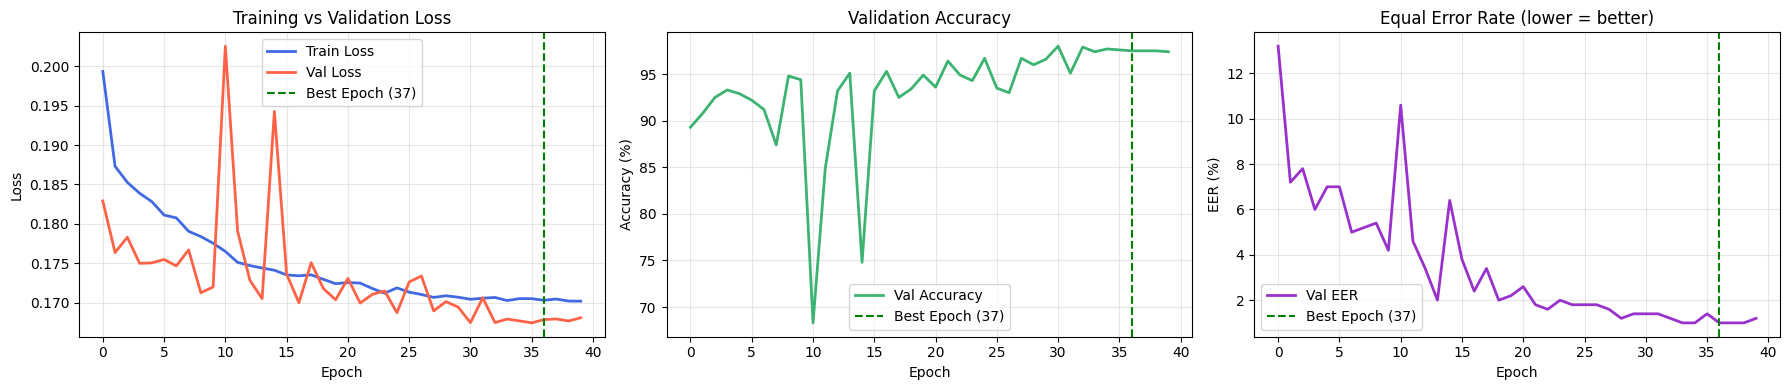

✅ Curves saved → /content/drive/MyDrive/deepfake_detector/models/medium_training_curves.png

  CONFIRMED PARAMETERS FOR FULL TRAINING
  LR          : 0.0005
  Temperature : 6.0
  Alpha       : 0.7
  Ideal Epochs: 37
  Best EER    : 1.00%
  Best Val Loss: 0.1674

Next → 4_training.ipynb for full training on 25,380 samples


In [8]:
# Load 5000 balanced samples
print("Loading medium training data...")
train_files_med, train_labels_med = load_asvspoof2019(
    config.DATASET_ROOT, config.AUDIO_DIRS, config.PROTOCOL_FILES,
    subset="train", max_samples=5000, balanced=True
)
val_files_med, val_labels_med = load_asvspoof2019(
    config.DATASET_ROOT, config.AUDIO_DIRS, config.PROTOCOL_FILES,
    subset="dev", max_samples=1000, balanced=True
)

assert train_labels_med.count(0) == train_labels_med.count(1), "FAIL: Train not balanced!"
assert val_labels_med.count(0)   == val_labels_med.count(1),   "FAIL: Val not balanced!"
print(f"✅ Class balance verified")

train_dataset_med = AudioDeepfakeDataset(train_files_med, train_labels_med, is_training=True)
val_dataset_med   = AudioDeepfakeDataset(val_files_med,   val_labels_med,   is_training=False)

train_loader_med = DataLoader(
    train_dataset_med, batch_size=config.BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True
)
val_loader_med = DataLoader(
    val_dataset_med, batch_size=config.BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f"  Train batches : {len(train_loader_med)}")
print(f"  Val batches   : {len(val_loader_med)}")

# Fresh student + optimizer
student_med  = MobileStudentCNN().to(device)
optimizer    = optim.Adam(student_med.parameters(), lr=best_lr)
scheduler    = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.MEDIUM_MAX_EPOCHS)
hard_loss_fn = nn.CrossEntropyLoss()
soft_loss_fn = nn.KLDivLoss(reduction="batchmean")

MAX_EPOCHS = config.MEDIUM_MAX_EPOCHS
PATIENCE   = config.MEDIUM_PATIENCE

best_eer                   = float('inf')
ideal_epoch                = 0
epochs_without_improvement = 0
train_loss_curve           = []
val_loss_curve             = []
val_acc_curve              = []
val_eer_curve              = []

print(f"\nStarting medium training...")
print(f"  LR          : {best_lr}")
print(f"  Temperature : {best_temp}")
print(f"  Alpha       : {best_alpha}")
print(f"  Max Epochs  : {MAX_EPOCHS} | Patience: {PATIENCE}\n")
print(f"  {'Epoch':<8} {'Train Loss':<12} {'Val Loss':<12} {'Val Acc':<10} {'EER':<8}")
print(f"  {'-'*52}")

for epoch in range(1, MAX_EPOCHS + 1):

    # --- Train ---
    student_med.train()
    train_loss = 0.0

    for raw_audio, mel_specs, true_labels in train_loader_med:
        raw_audio   = raw_audio.to(device)
        mel_specs   = mel_specs.to(device)
        true_labels = true_labels.to(device)

        optimizer.zero_grad()
        with torch.no_grad():
            teacher_logits = teacher(raw_audio)

        student_logits = student_med(mel_specs)
        loss, _, _     = kd_loss(
            student_logits, teacher_logits, true_labels,
            best_temp, best_alpha, hard_loss_fn, soft_loss_fn
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(student_med.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    scheduler.step()

    # --- Validate ---
    student_med.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    all_labels, all_scores = [], []

    with torch.no_grad():
        for raw_audio, mel_specs, true_labels in val_loader_med:
            raw_audio   = raw_audio.to(device)
            mel_specs   = mel_specs.to(device)
            true_labels = true_labels.to(device)

            teacher_logits = teacher(raw_audio)
            student_logits = student_med(mel_specs)
            loss, _, _     = kd_loss(
                student_logits, teacher_logits, true_labels,
                best_temp, best_alpha, hard_loss_fn, soft_loss_fn
            )
            val_loss    += loss.item()
            predicted    = torch.argmax(student_logits, dim=1)
            val_correct += (predicted == true_labels).sum().item()
            val_total   += true_labels.size(0)

            fake_scores = F.softmax(student_logits, dim=1)[:, 1]
            all_labels.extend(true_labels.cpu().numpy().tolist())
            all_scores.extend(fake_scores.cpu().numpy().tolist())

    avg_train_loss = train_loss / len(train_loader_med)
    avg_val_loss   = val_loss   / len(val_loader_med)
    avg_val_acc    = 100.0 * val_correct / val_total

    try:
        epoch_eer, _, _, _ = compute_eer(all_labels, all_scores)
    except Exception as e:
        epoch_eer = 99.0
        print(f"  [WARN] EER failed: {e}")

    train_loss_curve.append(avg_train_loss)
    val_loss_curve.append(avg_val_loss)
    val_acc_curve.append(avg_val_acc)
    val_eer_curve.append(epoch_eer)

    print(
        f"  [{epoch:02d}/{MAX_EPOCHS}]   "
        f"{avg_train_loss:<12.4f} "
        f"{avg_val_loss:<12.4f} "
        f"{avg_val_acc:<10.1f}% "
        f"{epoch_eer:<8.2f}%"
    )

    if epoch_eer < best_eer:
        best_eer                   = epoch_eer
        ideal_epoch                = epoch
        epochs_without_improvement = 0
        torch.save(student_med.state_dict(), f"{config.SAVE_DIR}/student_medium_best.pth")
        print(f"  💾 Best model saved — EER: {epoch_eer:.2f}%")
    else:
        epochs_without_improvement += 1
        print(f"  ⏳ No improvement ({epochs_without_improvement}/{PATIENCE})")
        if epochs_without_improvement >= PATIENCE:
            print(f"\n🛑 Early stopping at epoch {epoch} | Best EER: {best_eer:.2f}% at epoch {ideal_epoch}")
            break

# ==========================================
# Plot — Loss, Accuracy, EER
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(train_loss_curve, label="Train Loss", color="royalblue",     linewidth=2)
axes[0].plot(val_loss_curve,   label="Val Loss",   color="tomato",        linewidth=2)
axes[0].axvline(x=ideal_epoch-1, color="green", linestyle="--", linewidth=1.5, label=f"Best Epoch ({ideal_epoch})")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(val_acc_curve, label="Val Accuracy", color="mediumseagreen", linewidth=2)
axes[1].axvline(x=ideal_epoch-1, color="green", linestyle="--", linewidth=1.5, label=f"Best Epoch ({ideal_epoch})")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Validation Accuracy")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(val_eer_curve, label="Val EER", color="darkorchid",          linewidth=2)
axes[2].axvline(x=ideal_epoch-1, color="green", linestyle="--", linewidth=1.5, label=f"Best Epoch ({ideal_epoch})")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("EER (%)")
axes[2].set_title("Equal Error Rate (lower = better)")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{config.SAVE_DIR}/medium_training_curves.png", dpi=150)
plt.show()
print(f"✅ Curves saved → {config.SAVE_DIR}/medium_training_curves.png")

# ==========================================
# Summary
# ==========================================
print(f"\n{'='*55}")
print(f"  CONFIRMED PARAMETERS FOR FULL TRAINING")
print(f"{'='*55}")
print(f"  LR          : {best_lr}")
print(f"  Temperature : {best_temp}")
print(f"  Alpha       : {best_alpha}")
print(f"  Ideal Epochs: {ideal_epoch}")
print(f"  Best EER    : {best_eer:.2f}%")
print(f"  Best Val Loss: {min(val_loss_curve):.4f}")
print(f"{'='*55}")
print(f"\nNext → 4_training.ipynb for full training on 25,380 samples")

**Note on Scheduler Choice:**
Medium training uses `CosineAnnealingLR` which causes visible oscillation
in val loss and accuracy curves (spikes at epochs 11, 15). Full training
switches to `ReduceLROnPlateau` which automatically halves the LR when EER
stops improving — producing smoother convergence and better final EER
(0.30% dev EER vs 1.00% here on 5x more data).